✓ Ready
Loading: C:\python\Intelligent_Sketch2CAD\intermediate_data\adaptive_cleaned_20260510_143013.jpg


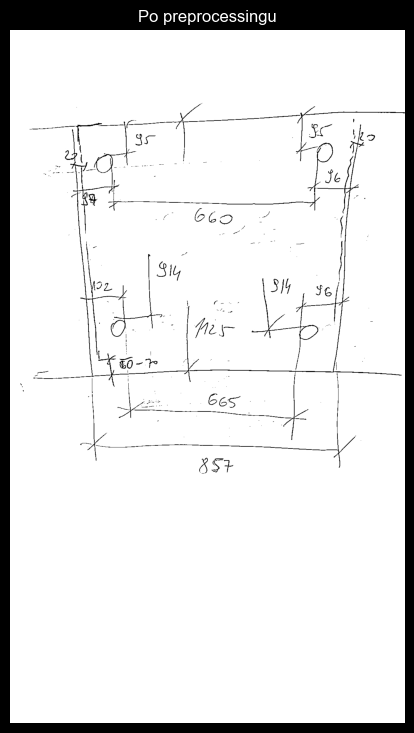

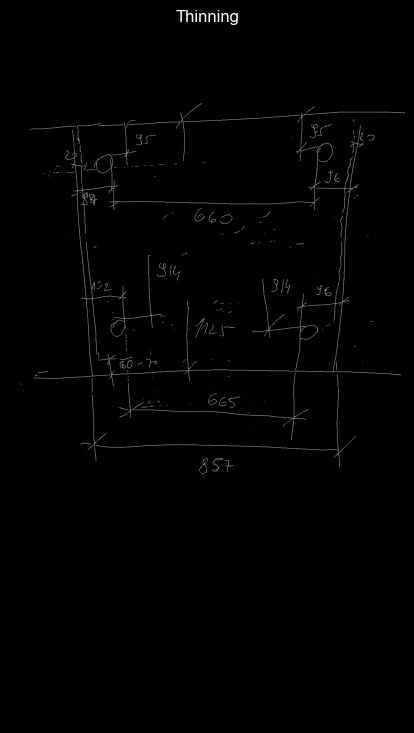

✓ Thinning OK

--- DeepLSD ---
✓ Model załadowany
DeepLSD: 344 segmentów


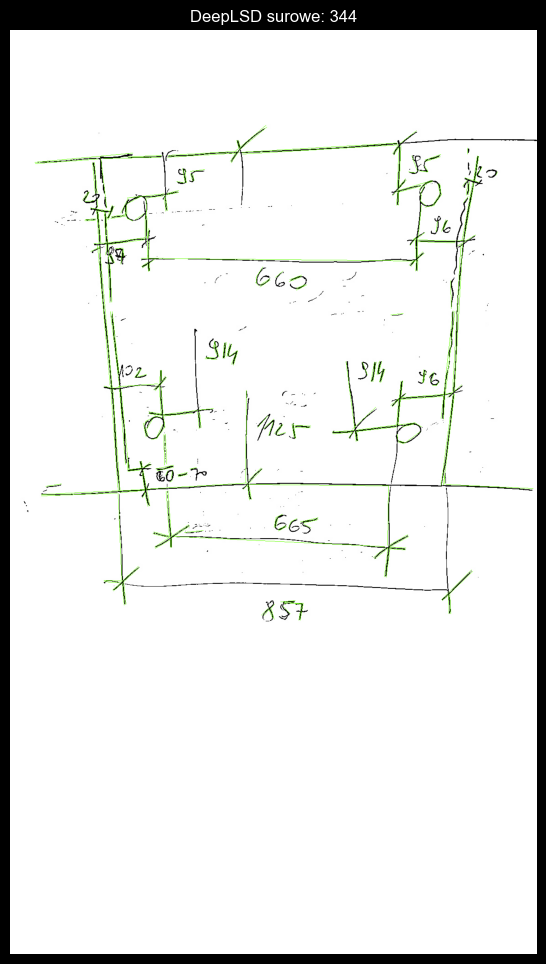


--- Klasyfikacja ---
main=54, wymiary=38, ticki=53


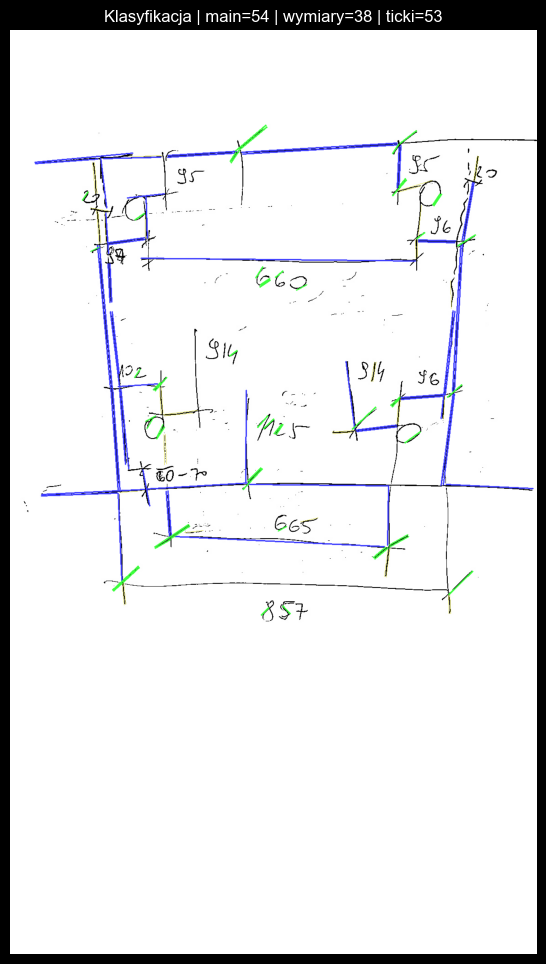


--- Krok 4: Prostokąt ---
Po filtracji: H=22, V=30
Linie H po filtracji:
  Y=257  len=339.6px  angle=176.7°
  Y=261  len=339.8px  angle=176.7°
  Y=270  len=150.3px  angle=176.5°
  Y=274  len=148.3px  angle=176.4°
  Y=279  len=214.9px  angle=174.7°
  Y=280  len=125.0px  angle=179.0°
  Y=287  len=137.4px  angle=175.6°
  Y=362  len=81.0px  angle=173.4°
  Y=460  len=80.5px  angle=172.0°
  Y=460  len=81.1px  angle=1.0°
  Y=464  len=80.5px  angle=171.9°
  Y=464  len=80.0px  angle=1.0°
  Y=777  len=86.5px  angle=176.4°
  Y=800  len=91.6px  angle=175.4°
  Y=804  len=92.4px  angle=175.7°
  Y=870  len=88.9px  angle=173.1°
  Y=873  len=87.6px  angle=173.2°
  Y=996  len=304.0px  angle=0.5°
  Y=998  len=219.4px  angle=176.8°
  Y=998  len=190.4px  angle=2.9°
  Y=1010  len=225.3px  angle=177.2°
  Y=1016  len=166.1px  angle=178.0°
Linie V po filtracji:
  X=204  len=109.8px  angle=83.1°
  X=205  len=312.2px  angle=84.7°
  X=209  len=312.2px  angle=84.8°
  X=212  len=90.1px  angle=86.2°
  X=216  len=84

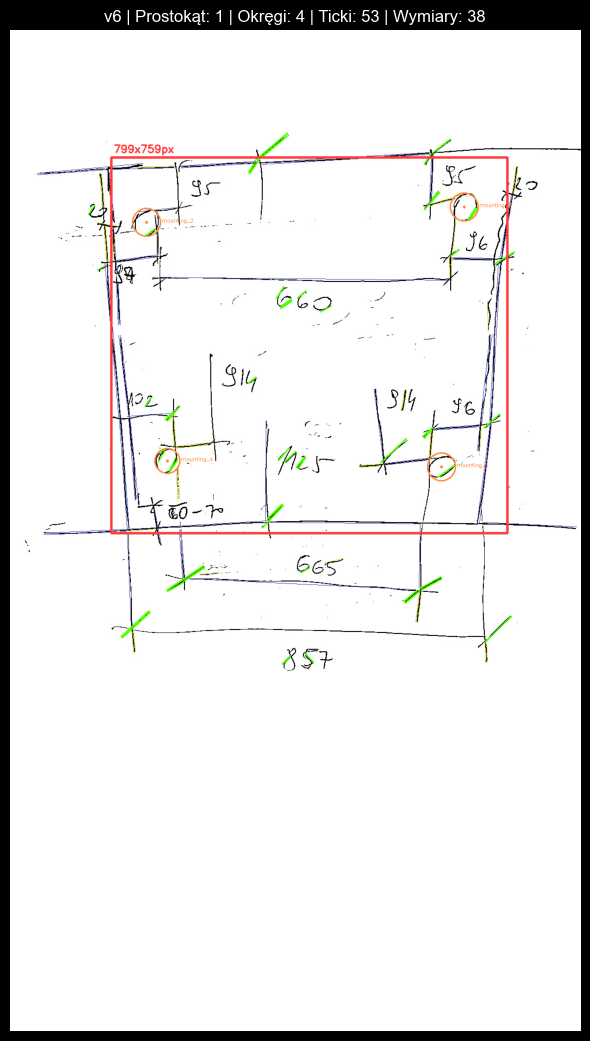


✅ C:\python\Intelligent_Sketch2CAD\intermediate_data\deeplsd_v6_20260511_095823.json
   Prostokąt: 1 | Okręgi: 4 | Ticki: 53 | Wymiary: 38

→ Następny krok: eksport DXF


In [1]:
# -------------------------------
# SKETCH → CAD: DeepLSD v6
# -------------------------------
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob
import os
import json
from datetime import datetime
import torch
import sys

print("✓ Ready")

PROJECT_DIR = Path(r"C:\python\Intelligent_Sketch2CAD")
INTERMEDIATE_DIR = PROJECT_DIR / "intermediate_data"
DEEPLSD_DIR = PROJECT_DIR / "DeepLSD"
WEIGHTS_PATH = DEEPLSD_DIR / "weights" / "deeplsd_md.tar"

pattern = str(INTERMEDIATE_DIR / "adaptive_cleaned_*.jpg")
files = glob.glob(pattern)
if not files:
    raise FileNotFoundError("No adaptive_cleaned_*.jpg found.")
latest_file = max(files, key=os.path.getctime)
print(f"Loading: {latest_file}")

image = cv2.imread(latest_file)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image
if np.mean(gray) < 128:
    gray = cv2.bitwise_not(gray)
    print("Polarity fixed")

# PREPROCESSING
contour_img = cv2.bitwise_not(gray)
contours, _ = cv2.findContours(contour_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if not contours:
    gray_filtered = gray
else:
    main_contour = max(contours, key=cv2.contourArea)
    mask_inside = np.zeros_like(gray, dtype=np.uint8)
    cv2.drawContours(mask_inside, [main_contour], -1, 255, thickness=cv2.FILLED)
    mask_edge = np.zeros_like(gray, dtype=np.uint8)
    cv2.drawContours(mask_edge, [main_contour], -1, 255, thickness=2)
    mask_near = cv2.dilate(mask_edge, np.ones((120, 120), np.uint8), iterations=1)
    cc_img = cv2.bitwise_not(gray)
    _, labels, stats, _ = cv2.connectedComponentsWithStats(cc_img, connectivity=8)
    mask_final = np.zeros_like(gray, dtype=np.uint8)
    for label in range(1, len(stats)):
        comp_mask = (labels == label).astype(np.uint8) * 255
        area = stats[label, cv2.CC_STAT_AREA]
        if cv2.bitwise_and(comp_mask, mask_inside).any():
            mask_final = cv2.bitwise_or(mask_final, comp_mask)
        elif cv2.bitwise_and(comp_mask, mask_near).any() and area < 1500:
            mask_final = cv2.bitwise_or(mask_final, comp_mask)
    gray_filtered = cv2.bitwise_and(gray, mask_final)
    gray_filtered[mask_final == 0] = 255
    gray = gray_filtered

plt.figure(figsize=(6,9))
plt.imshow(gray, cmap='gray'); plt.title("Po preprocessingu"); plt.axis('off'); plt.show()

# THINNING
binary_thin = cv2.bitwise_not(gray)
skeleton = cv2.ximgproc.thinning(binary_thin, thinningType=cv2.ximgproc.THINNING_ZHANGSUEN)
h, w = skeleton.shape
plt.figure(figsize=(6,9))
plt.imshow(skeleton, cmap='gray'); plt.title("Thinning"); plt.axis('off'); plt.show()
print("✓ Thinning OK")

# DEEPLSD
print("\n--- DeepLSD ---")
sys.path.insert(0, str(DEEPLSD_DIR))
from deeplsd.models.deeplsd_inference import DeepLSD

device = torch.device('cpu')
conf = {
    'detect_lines': True,
    'line_detection_params': {
        'merge': True, 'filtering': True,
        'grad_thresh': 2, 'grad_nfa': True,
    }
}
ckpt = torch.load(str(WEIGHTS_PATH), map_location=device, weights_only=False)
net = DeepLSD(conf)
net.load_state_dict(ckpt['model'])
net.eval()
print("✓ Model załadowany")

img_tensor = torch.tensor(gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0
with torch.no_grad():
    out = net({'image': img_tensor})

lines_raw = out['lines'][0]
print(f"DeepLSD: {len(lines_raw)} segmentów")

all_segments = []
for line in lines_raw:
    x1, y1 = float(line[0][0]), float(line[0][1])
    x2, y2 = float(line[1][0]), float(line[1][1])
    length = np.hypot(x2-x1, y2-y1)
    angle = np.degrees(np.arctan2(y2-y1, x2-x1)) % 180
    all_segments.append((int(x1), int(y1), int(x2), int(y2), length, angle))

vis_raw = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
for (x1,y1,x2,y2,l,a) in all_segments:
    cv2.line(vis_raw, (x1,y1), (x2,y2), (0,255,100), 1)
plt.figure(figsize=(8,12))
plt.imshow(cv2.cvtColor(vis_raw, cv2.COLOR_BGR2RGB))
plt.title(f"DeepLSD surowe: {len(all_segments)}")
plt.axis('off'); plt.show()

# KLASYFIKACJA
print("\n--- Klasyfikacja ---")
ANGLE_TOL_STRAIGHT = 20
ANGLE_TOL_TICK = 18
MIN_MAIN = 80
MIN_DIM  = 40
MIN_TICK = 20
MAX_TICK = 90

def classify_segment(x1, y1, x2, y2, length, angle):
    is_h = angle < ANGLE_TOL_STRAIGHT or angle > (180 - ANGLE_TOL_STRAIGHT)
    is_v = abs(angle - 90) < ANGLE_TOL_STRAIGHT
    is_tick = (abs(angle-45) < ANGLE_TOL_TICK or abs(angle-135) < ANGLE_TOL_TICK)
    if (is_h or is_v) and length >= MIN_MAIN:
        return "main"
    elif (is_h or is_v) and length >= MIN_DIM:
        return "dimension_line"
    elif is_tick and MIN_TICK <= length <= MAX_TICK:
        return "tick"
    elif length >= MIN_DIM:
        return "other"
    return "noise"

lines_main, lines_dimension, lines_tick, lines_other = [], [], [], []

for seg in all_segments:
    x1,y1,x2,y2,length,angle = seg
    typ = classify_segment(x1,y1,x2,y2,length,angle)
    entry = {"x1":x1,"y1":y1,"x2":x2,"y2":y2,
             "length_px":round(length,1),"angle_deg":round(angle,1)}
    if typ == "main":             lines_main.append(entry)
    elif typ == "dimension_line": lines_dimension.append(entry)
    elif typ == "tick":           lines_tick.append(entry)
    elif typ == "other":          lines_other.append(entry)

for l in lines_other:
    if l['length_px'] > 150:
        lines_main.append(l)

print(f"main={len(lines_main)}, wymiary={len(lines_dimension)}, ticki={len(lines_tick)}")

vis_class = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
for l in lines_main:
    cv2.line(vis_class, (l['x1'],l['y1']), (l['x2'],l['y2']), (255,60,60), 2)
for l in lines_dimension:
    cv2.line(vis_class, (l['x1'],l['y1']), (l['x2'],l['y2']), (60,220,220), 1)
for l in lines_tick:
    cv2.line(vis_class, (l['x1'],l['y1']), (l['x2'],l['y2']), (60,255,60), 2)
plt.figure(figsize=(8,12))
plt.imshow(cv2.cvtColor(vis_class, cv2.COLOR_BGR2RGB))
plt.title(f"Klasyfikacja | main={len(lines_main)} | wymiary={len(lines_dimension)} | ticki={len(lines_tick)}")
plt.axis('off'); plt.show()

# PROSTOKĄT
print("\n--- Krok 4: Prostokąt ---")

def mid_y(l): return (l['y1'] + l['y2']) / 2
def mid_x(l): return (l['x1'] + l['x2']) / 2

main_h = [l for l in lines_main
          if l['angle_deg'] < ANGLE_TOL_STRAIGHT or
             l['angle_deg'] > (180 - ANGLE_TOL_STRAIGHT)]
main_v = [l for l in lines_main
          if abs(l['angle_deg'] - 90) < ANGLE_TOL_STRAIGHT]

# Filtr: odrzuć linie pomocnicze (zbyt długie) i zbyt krótkie dla krawędzi
# Z danych: linia ściany Y=502 len=601 — odrzucamy > 550px
# Linia wymiarowa Y=1119 len=458 — to za długo jak na wymiarową ale short dla ściany
# Krawędzie prostokąta: Y=257 len=340, Y=995 len=304 — ~300-460px
MAX_H_LENGTH = 400 # powyżej = linia ściany
MIN_H_LENGTH = 80   # poniżej = szum

main_h_filtered = [l for l in main_h
                   if MIN_H_LENGTH <= l['length_px'] <= MAX_H_LENGTH]
main_v_filtered = [l for l in main_v
                   if l['length_px'] >= MIN_H_LENGTH]

print(f"Po filtracji: H={len(main_h_filtered)}, V={len(main_v_filtered)}")
print("Linie H po filtracji:")
for l in sorted(main_h_filtered, key=mid_y):
    print(f"  Y={mid_y(l):.0f}  len={l['length_px']}px  angle={l['angle_deg']}°")
print("Linie V po filtracji:")
for l in sorted(main_v_filtered, key=mid_x):
    print(f"  X={mid_x(l):.0f}  len={l['length_px']}px  angle={l['angle_deg']}°")

rectangles = []
if len(main_h_filtered) >= 2 and len(main_v_filtered) >= 2:
    top_line    = min(main_h_filtered, key=mid_y)
    bottom_line = max(main_h_filtered, key=mid_y)
    left_line   = min(main_v_filtered, key=mid_x)
    right_line  = max(main_v_filtered, key=mid_x)

    print(f"  Górna:  Y={mid_y(top_line):.0f}  len={top_line['length_px']}px")
    print(f"  Dolna:  Y={mid_y(bottom_line):.0f}  len={bottom_line['length_px']}px")
    print(f"  Lewa:   X={mid_x(left_line):.0f}  len={left_line['length_px']}px")
    print(f"  Prawa:  X={mid_x(right_line):.0f}  len={right_line['length_px']}px")

    x1r = int(mid_x(left_line))
    x2r = int(mid_x(right_line))
    y1r = int(mid_y(top_line))
    y2r = int(mid_y(bottom_line))

    rectangles.append({
        "label": "outer",
        "x1": x1r, "y1": y1r,
        "x2": x2r, "y2": y2r,
        "width_px":  x2r - x1r,
        "height_px": y2r - y1r
    })
    print(f"Prostokąt: ({x1r},{y1r})→({x2r},{y2r})  {x2r-x1r}x{y2r-y1r}px")
else:
    print("⚠ Za mało linii")

# OKRĘGI
print("\n--- Okręgi ---")
kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
skeleton_closed = cv2.morphologyEx(skeleton, cv2.MORPH_CLOSE, kernel_close)
circle_contours, _ = cv2.findContours(skeleton_closed, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

circles_all = []
for cnt in circle_contours:
    area = cv2.contourArea(cnt)
    if area < 300 or area > 12000: continue
    perimeter = cv2.arcLength(cnt, True)
    if perimeter < 1: continue
    circularity = 4 * np.pi * area / (perimeter ** 2)
    if circularity > 0.60:
        (cx,cy), radius = cv2.minEnclosingCircle(cnt)
        circles_all.append({"cx":int(cx),"cy":int(cy),
                             "radius_px":int(radius),"circularity":round(circularity,3)})

circles_clean = []
for c in sorted(circles_all, key=lambda x: -x['radius_px']):
    if not any(np.hypot(c['cx']-e['cx'],c['cy']-e['cy']) < 25 for e in circles_clean):
        circles_clean.append(c)

circles_mounting = sorted(circles_clean, key=lambda x: -x['radius_px'])[:4]
for i,c in enumerate(circles_mounting):
    c['label'] = f"mounting_{i+1}"
    c['radius_mm'] = None
    print(f"  {c['label']}: ({c['cx']},{c['cy']})  r={c['radius_px']}px")

# WIZUALIZACJA KOŃCOWA
print("\n--- Wizualizacja końcowa ---")
vis_final = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

for l in lines_dimension:
    cv2.line(vis_final, (l['x1'],l['y1']), (l['x2'],l['y2']), (0,200,200), 1)
for l in lines_tick:
    cv2.line(vis_final, (l['x1'],l['y1']), (l['x2'],l['y2']), (0,255,80), 2)
for l in lines_main:
    cv2.line(vis_final, (l['x1'],l['y1']), (l['x2'],l['y2']), (180,60,60), 1)
if rectangles:
    r = rectangles[0]
    cv2.rectangle(vis_final, (r['x1'],r['y1']), (r['x2'],r['y2']), (60,60,255), 3)
    cv2.putText(vis_final, f"{r['width_px']}x{r['height_px']}px",
                (r['x1']+5,r['y1']-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (60,60,255), 2)
for c in circles_mounting:
    cv2.circle(vis_final, (c['cx'],c['cy']), c['radius_px'], (60,140,255), 2)
    cv2.circle(vis_final, (c['cx'],c['cy']), 3, (60,140,255), -1)
    cv2.putText(vis_final, c['label'], (c['cx']+c['radius_px']+3,c['cy']),
                cv2.FONT_HERSHEY_SIMPLEX, 0.35, (60,140,255), 1)

plt.figure(figsize=(9,13))
plt.imshow(cv2.cvtColor(vis_final, cv2.COLOR_BGR2RGB))
plt.title(f"v6 | Prostokąt: {len(rectangles)} | Okręgi: {len(circles_mounting)} | "
          f"Ticki: {len(lines_tick)} | Wymiary: {len(lines_dimension)}")
plt.axis('off'); plt.show()

# ZAPIS JSON
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
data = {
    "timestamp": timestamp,
    "source_image": str(latest_file),
    "image_size": {"height": h, "width": w},
    "method": "DeepLSD v6 — filtered H/V + contour circles",
    "rectangles": rectangles,
    "circles": circles_mounting,
    "lines": {
        "main": lines_main,
        "dimension_lines": lines_dimension,
        "ticks": lines_tick,
    },
    "statistics": {
        "deeplsd_raw": len(all_segments),
        "main": len(lines_main),
        "dimension": len(lines_dimension),
        "ticks": len(lines_tick),
        "circles_mounting": len(circles_mounting)
    },
    "notes": {
        "scale_hint": "857mm = szerokość zewnętrzna"
    }
}

json_path = INTERMEDIATE_DIR / f"deeplsd_v6_{timestamp}.json"
with open(json_path, 'w') as f:
    json.dump(data, f, indent=2)

print(f"\n✅ {json_path}")
print(f"   Prostokąt: {len(rectangles)} | Okręgi: {len(circles_mounting)} | "
      f"Ticki: {len(lines_tick)} | Wymiary: {len(lines_dimension)}")
print("\n→ Następny krok: eksport DXF")

In [2]:
import ezdxf

doc = ezdxf.new('R2010')
msp = doc.modelspace()

# Prostokąt
if rectangles:
    r = rectangles[0]
    msp.add_lwpolyline([
        (r['x1'], -r['y1']),
        (r['x2'], -r['y1']),
        (r['x2'], -r['y2']),
        (r['x1'], -r['y2']),
        (r['x1'], -r['y1'])
    ], dxfattribs={'layer': 'RECTANGLE'})

# Okręgi
for c in circles_mounting:
    msp.add_circle(
        center=(c['cx'], -c['cy']),
        radius=c['radius_px'],
        dxfattribs={'layer': 'CIRCLES'}
    )

dxf_path = INTERMEDIATE_DIR / f"sketch_{timestamp}.dxf"
doc.saveas(str(dxf_path))
print(f"✅ DXF zapisany: {dxf_path}")

[05/11/2026 10:07:14 INFO] creating ACAD_COLOR dictionary
[05/11/2026 10:07:14 INFO] creating ACAD_GROUP dictionary
[05/11/2026 10:07:14 INFO] creating ACAD_LAYOUT dictionary
[05/11/2026 10:07:14 INFO] creating ACAD_MATERIAL dictionary
[05/11/2026 10:07:14 INFO] creating ACAD_MLEADERSTYLE dictionary
[05/11/2026 10:07:14 INFO] creating ACAD_MLINESTYLE dictionary
[05/11/2026 10:07:14 INFO] creating ACAD_PLOTSETTINGS dictionary
[05/11/2026 10:07:14 INFO] creating ACAD_PLOTSTYLENAME dictionary
[05/11/2026 10:07:14 INFO] creating ACAD_SCALELIST dictionary
[05/11/2026 10:07:14 INFO] creating ACAD_TABLESTYLE dictionary
[05/11/2026 10:07:14 INFO] creating ACAD_VISUALSTYLE dictionary
[05/11/2026 10:07:14 INFO] did not write header var $INTERFEREOBJVS, value is None.
[05/11/2026 10:07:14 INFO] did not write header var $INTERFEREVPVS, value is None.


✅ DXF zapisany: C:\python\Intelligent_Sketch2CAD\intermediate_data\sketch_20260511_095823.dxf


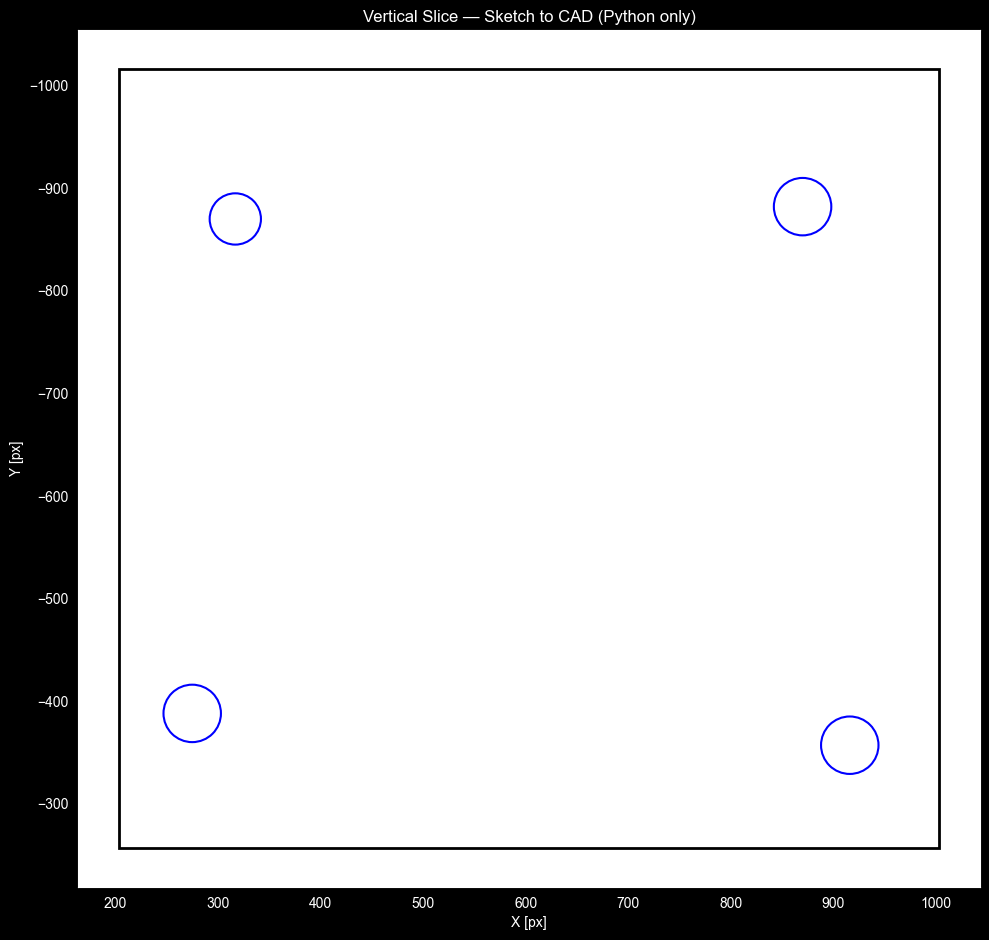

✅ Rysunek techniczny zapisany


In [3]:
import ezdxf
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(1, 1, figsize=(10, 12))
ax.set_aspect('equal')
ax.set_facecolor('white')

# Prostokąt
if rectangles:
    r = rectangles[0]
    rect = patches.Rectangle(
        (r['x1'], -r['y2']),
        r['width_px'], r['height_px'],
        linewidth=2, edgecolor='black', facecolor='none'
    )
    ax.add_patch(rect)

# Okręgi
for c in circles_mounting:
    circle = patches.Circle(
        (c['cx'], -c['cy']),
        c['radius_px'],
        linewidth=1.5, edgecolor='blue', facecolor='none'
    )
    ax.add_patch(circle)

ax.autoscale()
ax.invert_yaxis()
ax.set_title("Vertical Slice — Sketch to CAD (Python only)")
ax.set_xlabel("X [px]")
ax.set_ylabel("Y [px]")
plt.tight_layout()
plt.savefig(str(INTERMEDIATE_DIR / f"technical_drawing_{timestamp}.png"), dpi=150)
plt.show()
print("✅ Rysunek techniczny zapisany")

Loading: C:\python\Intelligent_Sketch2CAD\intermediate_data\deeplsd_v6_20260511_095823.json
Skala: 1.073 mm/px (X)  0.870 mm/px (Y)


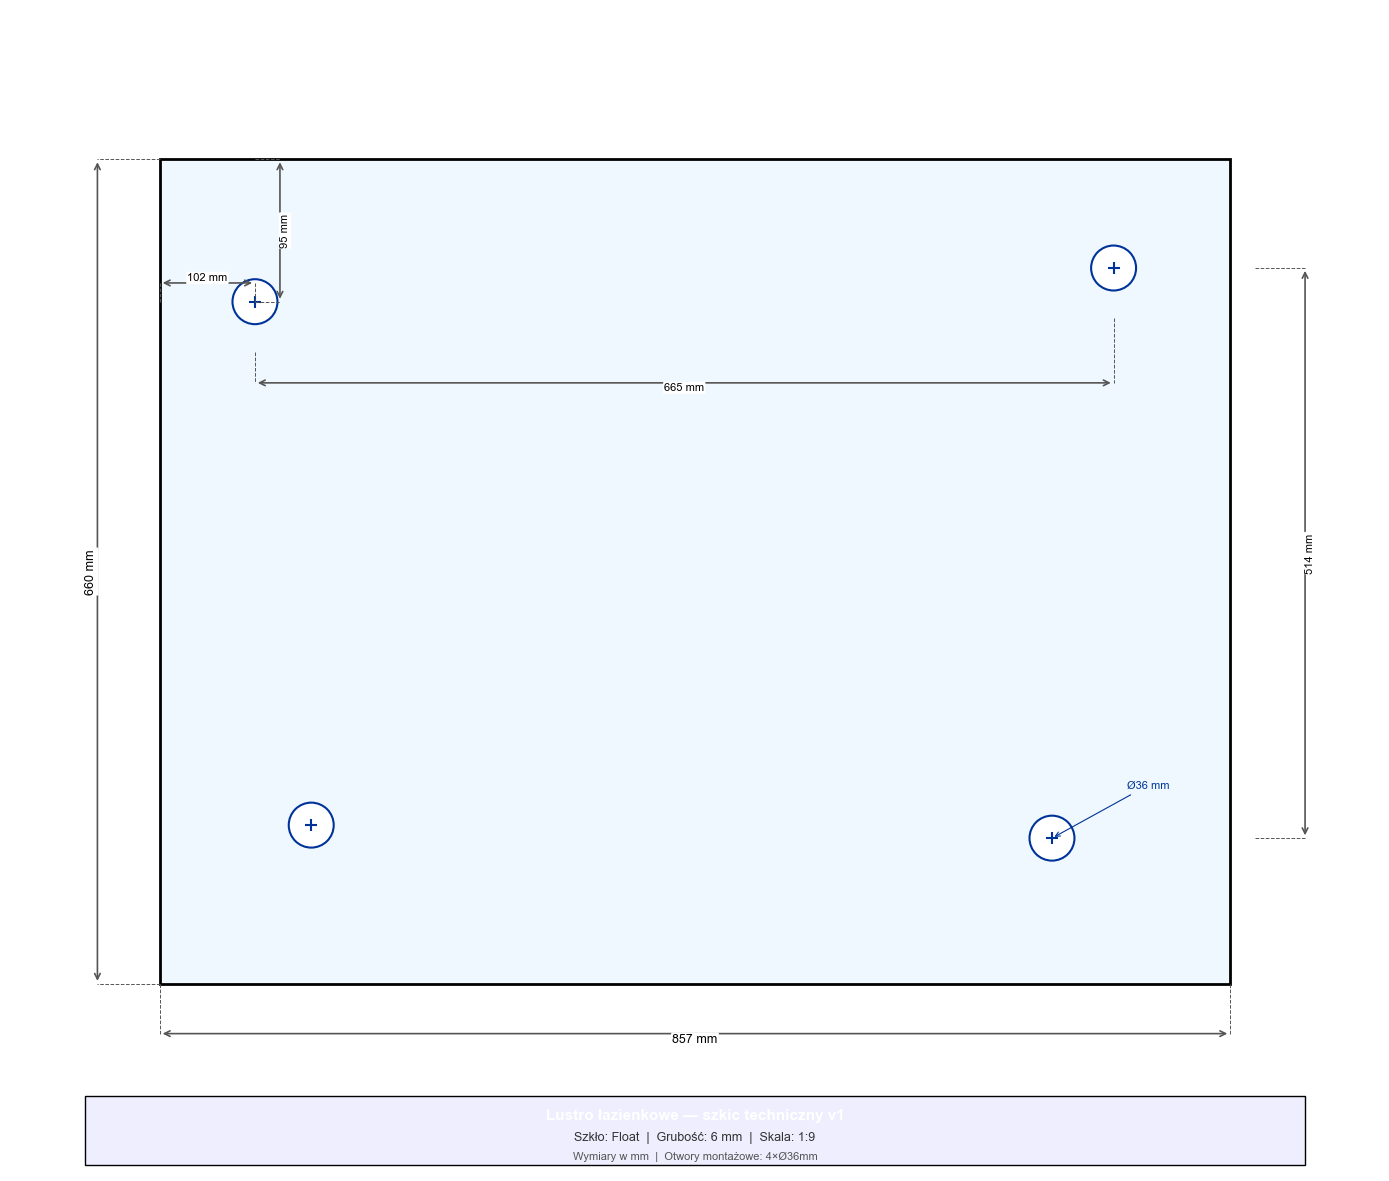

✅ PNG: C:\python\Intelligent_Sketch2CAD\intermediate_data\technical_drawing_final.png
✅ PDF: C:\python\Intelligent_Sketch2CAD\intermediate_data\technical_drawing_final.pdf

Vertical Slice KOMPLETNY:
  Szkic → DeepLSD → JSON → Rysunek techniczny → PDF
  Prostokąt: 857x660mm
  Okręgi: 4x Ø36mm
  Szkło: Float 6mm


In [4]:
# -------------------------------
# JSON → Rysunek Techniczny
# -------------------------------
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch
from pathlib import Path
import glob
import os

PROJECT_DIR = Path(r"C:\python\Intelligent_Sketch2CAD")
INTERMEDIATE_DIR = PROJECT_DIR / "intermediate_data"

# -------------------------------
# LOAD LATEST JSON
# -------------------------------
json_files = glob.glob(str(INTERMEDIATE_DIR / "deeplsd_v6_*.json"))
if not json_files:
    raise FileNotFoundError("No deeplsd_v6_*.json found.")
latest_json = max(json_files, key=os.path.getctime)
print(f"Loading: {latest_json}")

with open(latest_json, 'r') as f:
    data = json.load(f)

# -------------------------------
# WYMIARY — na razie ręczne, potem AI OCR
# -------------------------------
dims = {
    "width_mm":  857,
    "height_mm": 660,
    "offset_top_mm":    95,
    "offset_bottom_mm": 95,
    "offset_left_mm":  102,
    "offset_right_mm":  96,
    "hole_spacing_h_mm": 665,
    "hole_spacing_v_mm": 514,
    "hole_diameter_mm":  36,
    "glass_type": "Float",
    "glass_thickness_mm": 6,
    "note": "Lustro łazienkowe — szkic techniczny v1"
}

# -------------------------------
# KALIBRACJA px → mm
# -------------------------------
r = data['rectangles'][0]
width_px  = r['width_px']
height_px = r['height_px']

scale_x = dims['width_mm']  / width_px   # mm/px
scale_y = dims['height_mm'] / height_px  # mm/px
print(f"Skala: {scale_x:.3f} mm/px (X)  {scale_y:.3f} mm/px (Y)")

# Konwersja px → mm (origin = lewy górny róg prostokąta)
def to_mm(px_x, px_y):
    return (
        (px_x - r['x1']) * scale_x,
        (px_y - r['y1']) * scale_y
    )

W = dims['width_mm']
H = dims['height_mm']

# Okręgi w mm
circles_mm = []
for c in data['circles']:
    cx_mm, cy_mm = to_mm(c['cx'], c['cy'])
    circles_mm.append({
        'cx': cx_mm,
        'cy': cy_mm,
        'r':  dims['hole_diameter_mm'] / 2,
        'label': c['label']
    })

# -------------------------------
# RYSUNEK TECHNICZNY
# -------------------------------
MARGIN = 120  # margines na wymiary

fig, ax = plt.subplots(figsize=(14, 12))
ax.set_aspect('equal')
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.axis('off')

# --- Prostokąt główny ---
rect = patches.Rectangle(
    (0, 0), W, H,
    linewidth=2, edgecolor='black', facecolor='#f0f8ff'
)
ax.add_patch(rect)

# --- Okręgi ---
for c in circles_mm:
    circle = patches.Circle(
        (c['cx'], H - c['cy']),
        c['r'],
        linewidth=1.5, edgecolor='#003399', facecolor='white'
    )
    ax.add_patch(circle)
    # Krzyżyk środka
    ax.plot(c['cx'], H - c['cy'], '+', color='#003399', markersize=8, markeredgewidth=1.5)

# --- Pomocnicza funkcja: linia wymiarowa ---
def dim_line(ax, x1, y1, x2, y2, text, offset=0, orient='h', fontsize=9):
    """Rysuje linię wymiarową ze strzałkami i tekstem."""
    color = '#555555'
    arrow_kw = dict(arrowstyle='<->', color=color, lw=1.2,
                    mutation_scale=10)

    if orient == 'h':
        # Pozioma linia wymiarowa
        y = y1 + offset
        # Linie pomocnicze
        ax.plot([x1, x1], [y1, y], color=color, lw=0.7, ls='--')
        ax.plot([x2, x2], [y2, y], color=color, lw=0.7, ls='--')
        # Strzałka
        ax.annotate('', xy=(x2, y), xytext=(x1, y),
                    arrowprops=dict(arrowstyle='<->', color=color, lw=1.2))
        # Tekst
        ax.text((x1+x2)/2, y, text,
                ha='center', va='bottom' if offset > 0 else 'top',
                fontsize=fontsize, color='black',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white', edgecolor='none'))
    else:
        # Pionowa linia wymiarowa
        x = x1 + offset
        ax.plot([x1, x], [y1, y1], color=color, lw=0.7, ls='--')
        ax.plot([x2, x], [y2, y2], color=color, lw=0.7, ls='--')
        ax.annotate('', xy=(x, y2), xytext=(x, y1),
                    arrowprops=dict(arrowstyle='<->', color=color, lw=1.2))
        ax.text(x, (y1+y2)/2, text,
                ha='right' if offset < 0 else 'left',
                va='center', fontsize=fontsize, color='black', rotation=90,
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white', edgecolor='none'))

# --- Wymiary główne ---
# Szerokość (dół)
dim_line(ax, 0, 0, W, 0, f'{dims["width_mm"]} mm',
         offset=-40, orient='h')

# Wysokość (lewa)
dim_line(ax, 0, 0, 0, H, f'{dims["height_mm"]} mm',
         offset=-50, orient='v')

# --- Wymiary otworów od krawędzi ---
# Odległość lewego otworu od lewej krawędzi
if len(circles_mm) >= 1:
    c = circles_mm[1]  # lewy górny
    dim_line(ax, 0, H - c['cy'], c['cx'], H - c['cy'],
             f'{dims["offset_left_mm"]} mm', offset=15, orient='h', fontsize=8)

# Odległość górnego otworu od górnej krawędzi
if len(circles_mm) >= 1:
    c = circles_mm[1]  # lewy górny
    dim_line(ax, c['cx'], H, c['cx'], H - c['cy'],
             f'{dims["offset_top_mm"]} mm', offset=20, orient='v', fontsize=8)

# Rozstaw poziomy otworów (665mm)
if len(circles_mm) >= 2:
    c1 = min(circles_mm, key=lambda c: c['cx'])
    c2 = max(circles_mm, key=lambda c: c['cx'])
    dim_line(ax, c1['cx'], H - c1['cy'] - 40,
             c2['cx'], H - c2['cy'] - 40,
             f'{dims["hole_spacing_h_mm"]} mm',
             offset=-25, orient='h', fontsize=8)

# Rozstaw pionowy otworów
if len(circles_mm) >= 2:
    c_top = min(circles_mm, key=lambda c: c['cy'])
    c_bot = max(circles_mm, key=lambda c: c['cy'])
    dim_line(ax, W + 20, H - c_bot['cy'],
             W + 20, H - c_top['cy'],
             f'{dims["hole_spacing_v_mm"]} mm',
             offset=40, orient='v', fontsize=8)

# --- Średnica otworów (jedna adnotacja) ---
if circles_mm:
    c = circles_mm[0]
    ax.annotate(
        f'Ø{dims["hole_diameter_mm"]} mm',
        xy=(c['cx'], H - c['cy']),
        xytext=(c['cx'] + 60, H - c['cy'] + 40),
        fontsize=8, color='#003399',
        arrowprops=dict(arrowstyle='->', color='#003399', lw=0.8)
    )

# --- Ramka tytułowa ---
title_y = -90
ax.add_patch(patches.Rectangle(
    (-MARGIN/2, title_y - 55), W + MARGIN, 55,
    linewidth=1, edgecolor='black', facecolor='#eeeeff'
))
ax.text(W/2, title_y - 10,
        dims['note'],
        ha='center', va='top', fontsize=11, fontweight='bold')
ax.text(W/2, title_y - 28,
        f'Szkło: {dims["glass_type"]}  |  Grubość: {dims["glass_thickness_mm"]} mm  |  '
        f'Skala: 1:{int(1/scale_x*25.4/96*1000/25.4) if scale_x > 0 else "—"}',
        ha='center', va='top', fontsize=9, color='#333333')
ax.text(W/2, title_y - 44,
        f'Wymiary w mm  |  Otwory montażowe: 4×Ø{dims["hole_diameter_mm"]}mm',
        ha='center', va='top', fontsize=8, color='#555555')

# --- Ustaw zakres osi ---
ax.set_xlim(-MARGIN, W + MARGIN)
ax.set_ylim(title_y - 60, H + MARGIN)

plt.tight_layout()

# Zapis
output_path = INTERMEDIATE_DIR / "technical_drawing_final.png"
pdf_path    = INTERMEDIATE_DIR / "technical_drawing_final.pdf"
plt.savefig(str(output_path), dpi=150, bbox_inches='tight',
            facecolor='white')
plt.savefig(str(pdf_path), bbox_inches='tight', facecolor='white')
plt.show()

print(f"✅ PNG: {output_path}")
print(f"✅ PDF: {pdf_path}")
print("\nVertical Slice KOMPLETNY:")
print(f"  Szkic → DeepLSD → JSON → Rysunek techniczny → PDF")
print(f"  Prostokąt: {W}x{H}mm")
print(f"  Okręgi: {len(circles_mm)}x Ø{dims['hole_diameter_mm']}mm")
print(f"  Szkło: {dims['glass_type']} {dims['glass_thickness_mm']}mm")